# 🫁 Pneumonia Detection from Chest X-Ray Images
## Deep Learning-Based Image Classification Pipeline

---

## SECTION 1: Project Overview

### Problem Statement
Pneumonia is a life-threatening lung infection responsible for millions of deaths annually, especially in children under 5 and the elderly. Diagnosis traditionally requires a trained radiologist to interpret chest X-rays — a process that is slow, expensive, and limited in underserved regions.

This project builds a **binary image classifier** that automatically distinguishes **NORMAL** vs **PNEUMONIA** chest X-ray images using **deep learning and transfer learning**, enabling faster, scalable, and low-cost preliminary screening.

### Why It Matters
- ~2.5 million pneumonia deaths/year worldwide (WHO)
- Radiologist shortage in developing nations
- AI-assisted diagnosis can flag high-risk cases instantly
- Reduces diagnostic errors and turnaround time

### Approach
- Transfer learning with **DenseNet121** (pretrained on ImageNet)
- Binary classification: NORMAL (0) vs PNEUMONIA (1)
- Controlled experiments to improve performance
- Full evaluation: Accuracy, Precision, Recall, F1, AUC-ROC

### Dataset
**Chest X-Ray Images (Pneumonia)** from Kaggle
- ~5,800 images across train/val/test
- Source: Paul Mooney / Guangzhou Women and Children's Medical Center
- Classes: NORMAL, PNEUMONIA

---
## SECTION 2: Imports and Setup

In [1]:
# Install required packages (run once)
!pip install -q torchinfo kaggle

In [2]:
# ─────────────────────────────────────────────
# Core Imports
# ─────────────────────────────────────────────
import os
import random
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from pathlib import Path
from collections import Counter

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchinfo import summary

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# ─────────────────────────────────────────────
# Reproducibility Seed
# ─────────────────────────────────────────────
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()

# ─────────────────────────────────────────────
# Device Setup
# ─────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Using device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


---
## SECTION 3: Dataset Download and Extraction

We use the **Chest X-Ray Images (Pneumonia)** dataset from Kaggle.

**Steps:**
1. Upload your `kaggle.json` API token (from Kaggle → Account → Create New Token)
2. Run the cells below to download and extract the dataset

In [3]:
# ─────────────────────────────────────────────
# Upload kaggle.json and configure credentials
# ─────────────────────────────────────────────
from google.colab import files

print('📁 Upload your kaggle.json file:')
uploaded = files.upload()  # Upload kaggle.json here

# Move to the expected location
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
print('✅ kaggle.json configured successfully')

📁 Upload your kaggle.json file:


Saving kaggle (1).json to kaggle (1).json
cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
✅ kaggle.json configured successfully


In [4]:
# ─────────────────────────────────────────────
# Download Dataset from Kaggle
# ─────────────────────────────────────────────
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia -p /content/

# Extract the zip file
!unzip -q /content/chest-xray-pneumonia.zip -d /content/chest_xray
print('✅ Dataset extracted successfully')

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [02:25<00:00, 16.9MB/s]

✅ Dataset extracted successfully


In [5]:
# ─────────────────────────────────────────────
# Verify Directory Structure
# ─────────────────────────────────────────────
BASE_DIR = Path('/content/chest_xray/chest_xray')

# Some versions have an extra nested folder
if not (BASE_DIR / 'train').exists():
    BASE_DIR = Path('/content/chest_xray')

TRAIN_DIR = BASE_DIR / 'train'
VAL_DIR   = BASE_DIR / 'val'
TEST_DIR  = BASE_DIR / 'test'

print('📂 Dataset Directory Structure:')
for split_name, split_dir in [('TRAIN', TRAIN_DIR), ('VAL', VAL_DIR), ('TEST', TEST_DIR)]:
    print(f'\n  [{split_name}] → {split_dir}')
    if split_dir.exists():
        for cls_dir in sorted(split_dir.iterdir()):
            if cls_dir.is_dir():
                count = len(list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png')))
                print(f'    📁 {cls_dir.name}: {count} images')
    else:
        print(f'    ⚠️ Directory not found!')

CLASS_NAMES = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)
print(f'\n✅ Classes ({NUM_CLASSES}): {CLASS_NAMES}')

📂 Dataset Directory Structure:

  [TRAIN] → /content/chest_xray/chest_xray/train
    📁 NORMAL: 1341 images
    📁 PNEUMONIA: 3875 images

  [VAL] → /content/chest_xray/chest_xray/val
    📁 NORMAL: 8 images
    📁 PNEUMONIA: 8 images

  [TEST] → /content/chest_xray/chest_xray/test
    📁 NORMAL: 234 images
    📁 PNEUMONIA: 390 images

✅ Classes (2): ['NORMAL', 'PNEUMONIA']


---
## SECTION 4: Dataset Inspection

📊 Class Distribution:

Split      Test  Train  Val
Class                      
NORMAL      234   1341    8
PNEUMONIA   390   3875    8


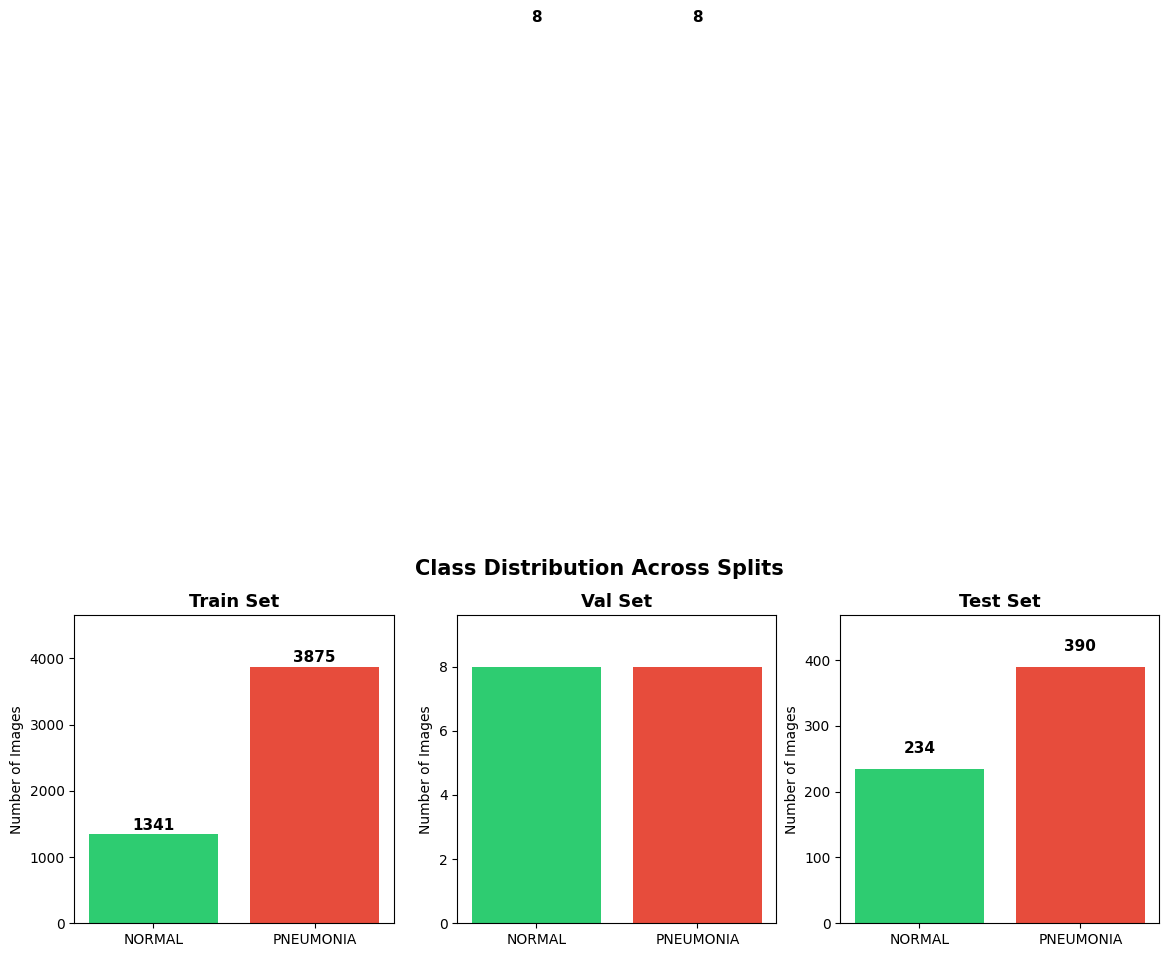


💾 Saved: class_distribution.png


In [6]:
# ─────────────────────────────────────────────
# Count images per class per split
# ─────────────────────────────────────────────
def count_images(directory):
    """Count images per class in a directory."""
    counts = {}
    for cls_dir in sorted(directory.iterdir()):
        if cls_dir.is_dir():
            imgs = list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.png'))
            counts[cls_dir.name] = len(imgs)
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts   = count_images(VAL_DIR)
test_counts  = count_images(TEST_DIR)

# Summary DataFrame
dist_df = pd.DataFrame({
    'Split': ['Train', 'Train', 'Val', 'Val', 'Test', 'Test'],
    'Class': list(train_counts.keys()) + list(val_counts.keys()) + list(test_counts.keys()),
    'Count': list(train_counts.values()) + list(val_counts.values()) + list(test_counts.values())
})
print('📊 Class Distribution:\n')
print(dist_df.pivot(index='Class', columns='Split', values='Count').to_string())

# Bar Plot
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#2ecc71', '#e74c3c']  # Green=NORMAL, Red=PNEUMONIA

for ax, (split_name, counts) in zip(axes, [('Train', train_counts), ('Val', val_counts), ('Test', test_counts)]):
    bars = ax.bar(counts.keys(), counts.values(), color=colors)
    ax.set_title(f'{split_name} Set', fontsize=13, fontweight='bold')
    ax.set_ylabel('Number of Images')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20, str(val),
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_ylim(0, max(counts.values()) * 1.2)

plt.suptitle('Class Distribution Across Splits', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n💾 Saved: class_distribution.png')

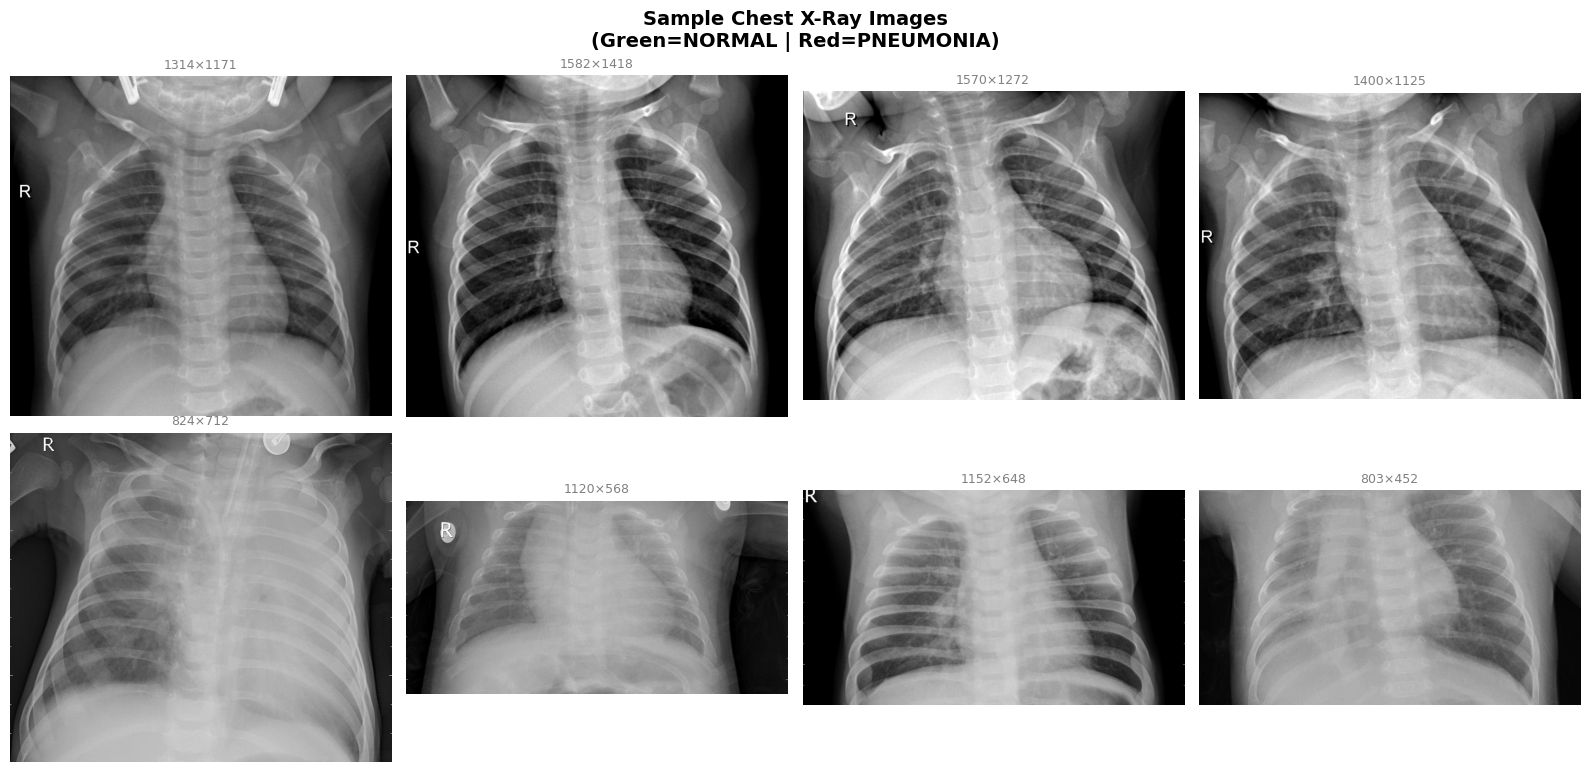

💾 Saved: sample_images.png


In [7]:
# ─────────────────────────────────────────────
# Visualize Sample Images
# ─────────────────────────────────────────────
def show_sample_images(train_dir, class_names, n_per_class=4):
    fig, axes = plt.subplots(len(class_names), n_per_class, figsize=(4*n_per_class, 4*len(class_names)))

    for row, cls in enumerate(class_names):
        cls_dir = train_dir / cls
        images = list(cls_dir.glob('*.jpeg'))[:n_per_class]
        for col, img_path in enumerate(images):
            img = Image.open(img_path).convert('RGB')
            axes[row, col].imshow(img, cmap='gray' if img.mode == 'L' else None)
            axes[row, col].axis('off')
            if col == 0:
                axes[row, col].set_ylabel(cls, fontsize=13, fontweight='bold', rotation=0,
                                          labelpad=60, va='center')
            axes[row, col].set_title(f'{img.size[0]}×{img.size[1]}', fontsize=9, color='gray')

    plt.suptitle('Sample Chest X-Ray Images\n(Green=NORMAL | Red=PNEUMONIA)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('💾 Saved: sample_images.png')

show_sample_images(TRAIN_DIR, CLASS_NAMES)

---
## SECTION 5: Preprocessing and Augmentation

### Transform Strategy
| Transform | Reason |
|-----------|--------|
| Resize(224×224) | DenseNet121 input requirement |
| RandomHorizontalFlip | X-rays can appear flipped; increases variety |
| RandomRotation(±10°) | Accounts for slight patient positioning variation |
| ColorJitter | Simulates different X-ray exposure levels |
| Normalize(ImageNet mean/std) | Required since we use ImageNet pretrained weights |
| CenterCrop (val/test) | No augmentation on validation — unbiased evaluation |

In [8]:
# ─────────────────────────────────────────────
# ImageNet normalization stats
# ─────────────────────────────────────────────
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE = 224

# ── Baseline transforms ──────────────────────
baseline_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── Stronger augmentation transforms (Experiment A) ──
strong_train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE + 20, IMG_SIZE + 20)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── Evaluation transform (val + test — NO augmentation) ──
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

print('✅ Transforms defined:')
print('  • baseline_train_transform')
print('  • strong_train_transform (Experiment A)')
print('  • eval_transform (val/test)')

✅ Transforms defined:
  • baseline_train_transform
  • strong_train_transform (Experiment A)
  • eval_transform (val/test)


---
## SECTION 6: DataLoaders

In [9]:
# ─────────────────────────────────────────────
# Hyperparameters
# ─────────────────────────────────────────────
BATCH_SIZE    = 32
NUM_WORKERS   = 2

def make_dataloaders(train_transform, batch_size=BATCH_SIZE, use_weighted_sampler=False):
    """
    Create train/val/test DataLoaders.
    use_weighted_sampler: handles class imbalance in training.
    """
    train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transform)
    val_dataset   = datasets.ImageFolder(VAL_DIR,   transform=eval_transform)
    test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=eval_transform)

    if use_weighted_sampler:
        # Compute class weights to handle imbalance
        class_counts = Counter([label for _, label in train_dataset.samples])
        total = sum(class_counts.values())
        class_weights = {cls: total / count for cls, count in class_counts.items()}
        sample_weights = [class_weights[label] for _, label in train_dataset.samples]
        sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)
        train_loader = DataLoader(train_dataset, batch_size=batch_size, sampler=sampler,
                                  num_workers=NUM_WORKERS, pin_memory=True)
    else:
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,
                                  num_workers=NUM_WORKERS, pin_memory=True)

    val_loader  = DataLoader(val_dataset,  batch_size=batch_size, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=True)

    print(f'📦 DataLoaders created:')
    print(f'   Train:  {len(train_dataset)} images | {len(train_loader)} batches')
    print(f'   Val:    {len(val_dataset)} images | {len(val_loader)} batches')
    print(f'   Test:   {len(test_dataset)} images | {len(test_loader)} batches')
    print(f'   Classes: {train_dataset.class_to_idx}')

    return train_loader, val_loader, test_loader, train_dataset.class_to_idx


# Create baseline dataloaders
train_loader, val_loader, test_loader, class_to_idx = make_dataloaders(
    baseline_train_transform, use_weighted_sampler=False
)

# NORMAL=0, PNEUMONIA=1 (ImageFolder assigns alphabetically)
IDX_TO_CLASS = {v: k for k, v in class_to_idx.items()}

📦 DataLoaders created:
   Train:  5216 images | 163 batches
   Val:    16 images | 1 batches
   Test:   624 images | 20 batches
   Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


---
## SECTION 7: Model Building — Baseline DenseNet121

We use **DenseNet121** pretrained on ImageNet.
- The backbone is **frozen** for the baseline (only the classifier head trains).
- The final `classifier` layer is replaced with a single output neuron for binary classification.
- We use `BCEWithLogitsLoss` (numerically stable sigmoid + BCE combined).

In [10]:
# ─────────────────────────────────────────────
# Model Factory Function
# ─────────────────────────────────────────────
def build_densenet121(freeze_backbone=True, dropout_p=0.5):
    """
    Build DenseNet121 for binary classification.
    freeze_backbone=True: Only train the classifier head.
    freeze_backbone=False: Fine-tune all layers.
    """
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # DenseNet121 classifier: Linear(1024 → num_classes)
    in_features = model.classifier.in_features  # 1024
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout_p),
        nn.Linear(in_features, 1)  # Single output → BCEWithLogitsLoss
    )

    return model


# Baseline: frozen backbone
baseline_model = build_densenet121(freeze_backbone=True, dropout_p=0.5)
baseline_model = baseline_model.to(DEVICE)

# Count trainable params
total_params     = sum(p.numel() for p in baseline_model.parameters())
trainable_params = sum(p.numel() for p in baseline_model.parameters() if p.requires_grad)
print(f'📐 DenseNet121 Architecture Summary:')
print(f'   Total parameters:     {total_params:,}')
print(f'   Trainable parameters: {trainable_params:,}  ({100*trainable_params/total_params:.2f}%)')
print(f'\n🔧 Classifier Head:')
print(baseline_model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 128MB/s]


📐 DenseNet121 Architecture Summary:
   Total parameters:     6,954,881
   Trainable parameters: 1,025  (0.01%)

🔧 Classifier Head:
Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=1024, out_features=1, bias=True)
)


---
## SECTION 8: Training Utilities

All reusable functions: train/validate one epoch, full training loop, metrics, early stopping, plotting.

In [11]:
# ─────────────────────────────────────────────
# Loss & Metrics Utilities
# ─────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob):
    """Compute all classification metrics."""
    return {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc_score(y_true, y_prob) if len(set(y_true)) > 1 else 0.0
    }


# ─────────────────────────────────────────────
# Train One Epoch
# ─────────────────────────────────────────────
def train_one_epoch(model, loader, criterion, optimizer, device, scaler=None):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

        optimizer.zero_grad()

        if scaler:  # Mixed precision
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) >= 0.5).long()
        correct += (preds == labels.long()).sum().item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


# ─────────────────────────────────────────────
# Validate One Epoch
# ─────────────────────────────────────────────
def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.float().unsqueeze(1).to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            preds = (torch.sigmoid(outputs) >= 0.5).long()
            correct += (preds == labels.long()).sum().item()
            total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc  = correct / total
    return epoch_loss, epoch_acc


# ─────────────────────────────────────────────
# Full Training Loop with Early Stopping
# ─────────────────────────────────────────────
def train_model(model, train_loader, val_loader, optimizer, scheduler, criterion,
                num_epochs=10, save_path='best_model.pth', patience=5, use_amp=True):
    """
    Complete training loop.
    Returns history dict with train/val loss and accuracy.
    """
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())
    early_stop_counter = 0
    scaler = torch.cuda.amp.GradScaler() if (use_amp and DEVICE.type == 'cuda') else None

    print(f'\n{'─'*60}')
    print(f'  Training: {num_epochs} epochs | Patience: {patience}')
    print(f'  AMP: {scaler is not None} | Device: {DEVICE}')
    print(f'{'─'*60}')

    start_time = time.time()

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
        v_loss, v_acc = validate_one_epoch(model, val_loader, criterion, DEVICE)

        if scheduler:
            if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(v_loss)
            else:
                scheduler.step()

        history['train_loss'].append(t_loss)
        history['val_loss'].append(v_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # Save best model
        if v_acc > best_val_acc:
            best_val_acc = v_acc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            marker = ' ✅ BEST'
            early_stop_counter = 0
        else:
            marker = ''
            early_stop_counter += 1

        lr = optimizer.param_groups[0]['lr']
        print(f'  Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f}  |  '
              f'Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}  '
              f'lr={lr:.2e}{marker}')

        if early_stop_counter >= patience:
            print(f'\n  ⏹️ Early stopping triggered at epoch {epoch}')
            break

    total_time = time.time() - start_time
    print(f'\n  ⏱️ Training complete in {total_time/60:.1f} min')
    print(f'  🏆 Best Val Accuracy: {best_val_acc:.4f}')
    print(f'  💾 Best weights saved to: {save_path}')

    # Load best weights back
    model.load_state_dict(best_weights)
    history['training_time'] = total_time
    history['best_val_acc']  = best_val_acc
    return model, history


# ─────────────────────────────────────────────
# Test Set Evaluation
# ─────────────────────────────────────────────
def evaluate_on_test(model, loader, device):
    """Full test set evaluation. Returns all metrics and raw predictions."""
    model.eval()
    all_probs, all_preds, all_labels = [], [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device, non_blocking=True)
            outputs = model(inputs)
            probs = torch.sigmoid(outputs).squeeze(1).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return metrics, np.array(all_labels), np.array(all_preds), np.array(all_probs)


# ─────────────────────────────────────────────
# Plotting Utilities
# ─────────────────────────────────────────────
def plot_training_curves(history, title='Training Curves', save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    axes[0].plot(epochs, history['train_loss'], 'b-o', label='Train Loss', markersize=4)
    axes[0].plot(epochs, history['val_loss'],   'r-o', label='Val Loss',   markersize=4)
    axes[0].set_title('Loss', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(epochs, [a*100 for a in history['train_acc']], 'b-o', label='Train Acc', markersize=4)
    axes[1].plot(epochs, [a*100 for a in history['val_acc']],   'r-o', label='Val Acc',   markersize=4)
    axes[1].set_title('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle(title, fontsize=15, fontweight='bold')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved: {save_path}')
    plt.show()


def plot_confusion_matrix(y_true, y_pred, class_names, title='Confusion Matrix', save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names,
                linewidths=0.5, linecolor='black')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved: {save_path}')
    plt.show()


def plot_roc_curve(y_true, y_prob, title='ROC Curve', save_path=None):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, 'b-', lw=2, label=f'ROC (AUC = {auc:.4f})')
    ax.plot([0, 1], [0, 1], 'r--', lw=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(loc='lower right', fontsize=11)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'💾 Saved: {save_path}')
    plt.show()


print('✅ All training utilities defined.')

✅ All training utilities defined.


---
## SECTION 9: Baseline Training

**Configuration:**
- DenseNet121 with frozen backbone
- Adam optimizer, lr=1e-3
- ReduceLROnPlateau scheduler
- 10 epochs, patience=4

In [13]:
# ─────────────────────────────────────────────
# Baseline Experiment Setup
# ─────────────────────────────────────────────
set_seed(42)

baseline_model = build_densenet121(freeze_backbone=True, dropout_p=0.5).to(DEVICE)

criterion      = nn.BCEWithLogitsLoss()
optimizer_b    = optim.Adam(filter(lambda p: p.requires_grad, baseline_model.parameters()), lr=1e-3)
scheduler_b    = optim.lr_scheduler.ReduceLROnPlateau(optimizer_b, mode='min', factor=0.5, patience=2)

baseline_model, baseline_history = train_model(
    model=baseline_model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer_b,
    scheduler=scheduler_b,
    criterion=criterion,
    num_epochs=10,
    save_path='/content/baseline_best.pth',
    patience=4,
    use_amp=True
)


────────────────────────────────────────────────────────────
  Training: 10 epochs | Patience: 4
  AMP: True | Device: cuda
────────────────────────────────────────────────────────────
  Epoch [01/10]  Train Loss: 0.4124  Acc: 0.8190  |  Val Loss: 0.3550  Acc: 1.0000  lr=1.00e-03 ✅ BEST
  Epoch [02/10]  Train Loss: 0.2794  Acc: 0.8855  |  Val Loss: 0.3097  Acc: 0.9375  lr=1.00e-03
  Epoch [03/10]  Train Loss: 0.2604  Acc: 0.8934  |  Val Loss: 0.3034  Acc: 0.8750  lr=1.00e-03
  Epoch [04/10]  Train Loss: 0.2383  Acc: 0.9013  |  Val Loss: 0.2438  Acc: 1.0000  lr=1.00e-03
  Epoch [05/10]  Train Loss: 0.2340  Acc: 0.9057  |  Val Loss: 0.2827  Acc: 0.9375  lr=1.00e-03

  ⏹️ Early stopping triggered at epoch 5

  ⏱️ Training complete in 6.6 min
  🏆 Best Val Accuracy: 1.0000
  💾 Best weights saved to: /content/baseline_best.pth


💾 Saved: /content/baseline_curves.png


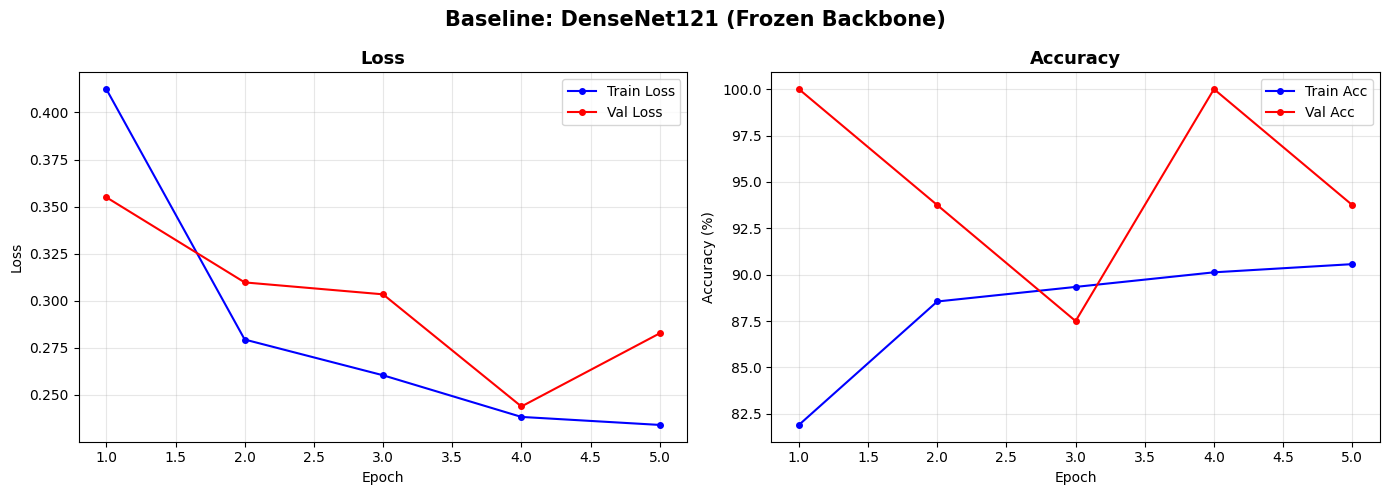

In [14]:
# Plot baseline training curves
plot_training_curves(baseline_history,
                     title='Baseline: DenseNet121 (Frozen Backbone)',
                     save_path='/content/baseline_curves.png')

---
## SECTION 10: Baseline Evaluation on Test Set

In [15]:
# ─────────────────────────────────────────────
# Load best baseline weights and evaluate
# ─────────────────────────────────────────────
baseline_model.load_state_dict(torch.load('/content/baseline_best.pth'))

b_metrics, b_labels, b_preds, b_probs = evaluate_on_test(baseline_model, test_loader, DEVICE)

print('\n' + '='*55)
print('  BASELINE TEST SET EVALUATION')
print('='*55)
print(f'  Accuracy:  {b_metrics["accuracy"]:.4f}')
print(f'  Precision: {b_metrics["precision"]:.4f}')
print(f'  Recall:    {b_metrics["recall"]:.4f}')
print(f'  F1-Score:  {b_metrics["f1"]:.4f}')
print(f'  ROC-AUC:   {b_metrics["roc_auc"]:.4f}')
print('='*55)

print('\n📋 Classification Report:')
print(classification_report(b_labels, b_preds, target_names=CLASS_NAMES))


  BASELINE TEST SET EVALUATION
  Accuracy:  0.8462
  Precision: 0.8372
  Recall:    0.9359
  F1-Score:  0.8838
  ROC-AUC:   0.9285

📋 Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.87      0.70      0.77       234
   PNEUMONIA       0.84      0.94      0.88       390

    accuracy                           0.85       624
   macro avg       0.85      0.82      0.83       624
weighted avg       0.85      0.85      0.84       624



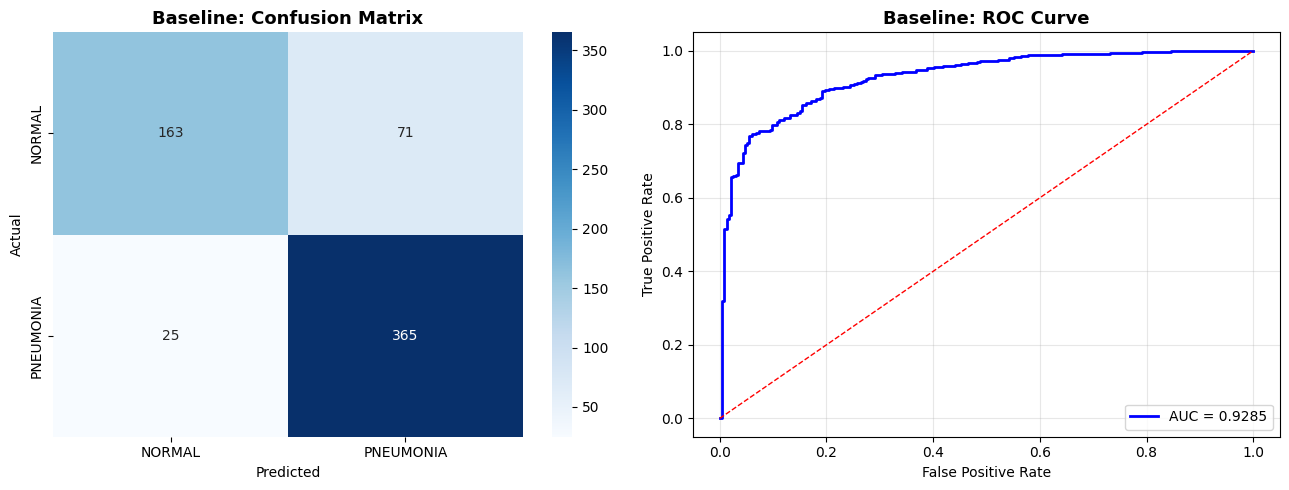

💾 Saved: baseline_eval.png


In [16]:
# Confusion Matrix + ROC Curve side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(b_labels, b_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Baseline: Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

# ROC Curve
fpr, tpr, _ = roc_curve(b_labels, b_probs)
auc_val = roc_auc_score(b_labels, b_probs)
axes[1].plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc_val:.4f}')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1)
axes[1].set_title('Baseline: ROC Curve', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/baseline_eval.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: baseline_eval.png')

---
## SECTION 11: Improvement Experiments

| # | Experiment | Change from Baseline |
|---|-----------|---------------------|
| A | Strong Augmentation | ColorJitter, RandomAffine, RandomCrop |
| B | Fine-tuning (unfreeze all layers) | Unfreeze backbone, lower lr=1e-4 |
| C | AdamW + Cosine LR | Switch optimizer and scheduler |
| D | Class-weighted Sampler + Fine-tune | Handle imbalance + fine-tune |

Results are stored and compared in Section 12.

In [17]:
# ─────────────────────────────────────────────
# Experiment A: Stronger Augmentation
# ─────────────────────────────────────────────
print('🧪 EXPERIMENT A: Strong Augmentation (Frozen Backbone)')
set_seed(42)

# Use strong augmentation
train_loader_a, _, _, _ = make_dataloaders(strong_train_transform)

model_a = build_densenet121(freeze_backbone=True, dropout_p=0.5).to(DEVICE)
opt_a   = optim.Adam(filter(lambda p: p.requires_grad, model_a.parameters()), lr=1e-3)
sch_a   = optim.lr_scheduler.ReduceLROnPlateau(opt_a, mode='min', factor=0.5, patience=2)

model_a, hist_a = train_model(
    model=model_a, train_loader=train_loader_a, val_loader=val_loader,
    optimizer=opt_a, scheduler=sch_a, criterion=criterion,
    num_epochs=10, save_path='/content/expA_best.pth', patience=4
)

model_a.load_state_dict(torch.load('/content/expA_best.pth'))
a_metrics, a_labels, a_preds, a_probs = evaluate_on_test(model_a, test_loader, DEVICE)
print(f'\n  Test Accuracy: {a_metrics["accuracy"]:.4f} | F1: {a_metrics["f1"]:.4f} | AUC: {a_metrics["roc_auc"]:.4f}')

🧪 EXPERIMENT A: Strong Augmentation (Frozen Backbone)
📦 DataLoaders created:
   Train:  5216 images | 163 batches
   Val:    16 images | 1 batches
   Test:   624 images | 20 batches
   Classes: {'NORMAL': 0, 'PNEUMONIA': 1}

────────────────────────────────────────────────────────────
  Training: 10 epochs | Patience: 4
  AMP: True | Device: cuda
────────────────────────────────────────────────────────────
  Epoch [01/10]  Train Loss: 0.4578  Acc: 0.7864  |  Val Loss: 0.4919  Acc: 0.6875  lr=1.00e-03 ✅ BEST
  Epoch [02/10]  Train Loss: 0.3370  Acc: 0.8497  |  Val Loss: 0.4466  Acc: 0.6875  lr=1.00e-03
  Epoch [03/10]  Train Loss: 0.3095  Acc: 0.8702  |  Val Loss: 0.4493  Acc: 0.7500  lr=1.00e-03 ✅ BEST
  Epoch [04/10]  Train Loss: 0.2852  Acc: 0.8821  |  Val Loss: 0.3733  Acc: 0.8125  lr=1.00e-03 ✅ BEST
  Epoch [05/10]  Train Loss: 0.2836  Acc: 0.8760  |  Val Loss: 0.3669  Acc: 0.8125  lr=1.00e-03
  Epoch [06/10]  Train Loss: 0.2868  Acc: 0.8754  |  Val Loss: 0.3568  Acc: 0.8125  lr=1.

In [18]:
# ─────────────────────────────────────────────
# Experiment B: Full Fine-tuning (Unfreeze All)
# ─────────────────────────────────────────────
print('🧪 EXPERIMENT B: Full Fine-tuning (Unfrozen Backbone)')
set_seed(42)

model_b = build_densenet121(freeze_backbone=False, dropout_p=0.4).to(DEVICE)  # All layers trainable

# Lower LR for fine-tuning to avoid destroying pretrained features
opt_b = optim.Adam(model_b.parameters(), lr=1e-4, weight_decay=1e-5)
sch_b = optim.lr_scheduler.StepLR(opt_b, step_size=3, gamma=0.5)

model_b, hist_b = train_model(
    model=model_b, train_loader=train_loader, val_loader=val_loader,
    optimizer=opt_b, scheduler=sch_b, criterion=criterion,
    num_epochs=10, save_path='/content/expB_best.pth', patience=4
)

model_b.load_state_dict(torch.load('/content/expB_best.pth'))
b_metrics_exp, b_labels_exp, b_preds_exp, b_probs_exp = evaluate_on_test(model_b, test_loader, DEVICE)
print(f'\n  Test Accuracy: {b_metrics_exp["accuracy"]:.4f} | F1: {b_metrics_exp["f1"]:.4f} | AUC: {b_metrics_exp["roc_auc"]:.4f}')

🧪 EXPERIMENT B: Full Fine-tuning (Unfrozen Backbone)

────────────────────────────────────────────────────────────
  Training: 10 epochs | Patience: 4
  AMP: True | Device: cuda
────────────────────────────────────────────────────────────
  Epoch [01/10]  Train Loss: 0.1451  Acc: 0.9434  |  Val Loss: 0.1810  Acc: 0.9375  lr=1.00e-04 ✅ BEST
  Epoch [02/10]  Train Loss: 0.0684  Acc: 0.9772  |  Val Loss: 0.4508  Acc: 0.6875  lr=1.00e-04
  Epoch [03/10]  Train Loss: 0.0467  Acc: 0.9835  |  Val Loss: 0.1653  Acc: 0.9375  lr=5.00e-05
  Epoch [04/10]  Train Loss: 0.0285  Acc: 0.9918  |  Val Loss: 0.0629  Acc: 1.0000  lr=5.00e-05 ✅ BEST
  Epoch [05/10]  Train Loss: 0.0295  Acc: 0.9896  |  Val Loss: 0.2102  Acc: 0.9375  lr=5.00e-05
  Epoch [06/10]  Train Loss: 0.0181  Acc: 0.9944  |  Val Loss: 0.0165  Acc: 1.0000  lr=2.50e-05
  Epoch [07/10]  Train Loss: 0.0125  Acc: 0.9967  |  Val Loss: 0.0490  Acc: 1.0000  lr=2.50e-05
  Epoch [08/10]  Train Loss: 0.0124  Acc: 0.9967  |  Val Loss: 0.1388  Acc:

In [19]:
# ─────────────────────────────────────────────
# Experiment C: AdamW + Cosine Annealing LR
# ─────────────────────────────────────────────
print('🧪 EXPERIMENT C: AdamW Optimizer + CosineAnnealingLR')
set_seed(42)

model_c = build_densenet121(freeze_backbone=False, dropout_p=0.4).to(DEVICE)
opt_c   = optim.AdamW(model_c.parameters(), lr=5e-5, weight_decay=1e-4)
sch_c   = optim.lr_scheduler.CosineAnnealingLR(opt_c, T_max=10, eta_min=1e-7)

model_c, hist_c = train_model(
    model=model_c, train_loader=train_loader, val_loader=val_loader,
    optimizer=opt_c, scheduler=sch_c, criterion=criterion,
    num_epochs=12, save_path='/content/expC_best.pth', patience=5
)

model_c.load_state_dict(torch.load('/content/expC_best.pth'))
c_metrics, c_labels, c_preds, c_probs = evaluate_on_test(model_c, test_loader, DEVICE)
print(f'\n  Test Accuracy: {c_metrics["accuracy"]:.4f} | F1: {c_metrics["f1"]:.4f} | AUC: {c_metrics["roc_auc"]:.4f}')

🧪 EXPERIMENT C: AdamW Optimizer + CosineAnnealingLR

────────────────────────────────────────────────────────────
  Training: 12 epochs | Patience: 5
  AMP: True | Device: cuda
────────────────────────────────────────────────────────────
  Epoch [01/12]  Train Loss: 0.1941  Acc: 0.9264  |  Val Loss: 0.1825  Acc: 0.9375  lr=4.88e-05 ✅ BEST
  Epoch [02/12]  Train Loss: 0.0742  Acc: 0.9766  |  Val Loss: 0.2065  Acc: 0.8125  lr=4.52e-05
  Epoch [03/12]  Train Loss: 0.0538  Acc: 0.9818  |  Val Loss: 0.2699  Acc: 0.8125  lr=3.97e-05
  Epoch [04/12]  Train Loss: 0.0392  Acc: 0.9866  |  Val Loss: 0.1252  Acc: 1.0000  lr=3.28e-05 ✅ BEST
  Epoch [05/12]  Train Loss: 0.0366  Acc: 0.9887  |  Val Loss: 0.1733  Acc: 0.9375  lr=2.50e-05
  Epoch [06/12]  Train Loss: 0.0233  Acc: 0.9939  |  Val Loss: 0.0445  Acc: 1.0000  lr=1.73e-05
  Epoch [07/12]  Train Loss: 0.0187  Acc: 0.9962  |  Val Loss: 0.0275  Acc: 1.0000  lr=1.04e-05
  Epoch [08/12]  Train Loss: 0.0199  Acc: 0.9946  |  Val Loss: 0.0457  Acc: 

In [20]:
# ─────────────────────────────────────────────
# Experiment D: Weighted Sampler + Fine-tune
# ─────────────────────────────────────────────
print('🧪 EXPERIMENT D: Weighted Sampler (handle imbalance) + Fine-tune')
set_seed(42)

# Weighted sampler to balance classes
train_loader_d, _, _, _ = make_dataloaders(strong_train_transform, use_weighted_sampler=True)

model_d = build_densenet121(freeze_backbone=False, dropout_p=0.3).to(DEVICE)
opt_d   = optim.AdamW(model_d.parameters(), lr=5e-5, weight_decay=1e-4)
sch_d   = optim.lr_scheduler.CosineAnnealingLR(opt_d, T_max=12, eta_min=1e-7)

model_d, hist_d = train_model(
    model=model_d, train_loader=train_loader_d, val_loader=val_loader,
    optimizer=opt_d, scheduler=sch_d, criterion=criterion,
    num_epochs=12, save_path='/content/expD_best.pth', patience=5
)

model_d.load_state_dict(torch.load('/content/expD_best.pth'))
d_metrics, d_labels, d_preds, d_probs = evaluate_on_test(model_d, test_loader, DEVICE)
print(f'\n  Test Accuracy: {d_metrics["accuracy"]:.4f} | F1: {d_metrics["f1"]:.4f} | AUC: {d_metrics["roc_auc"]:.4f}')

🧪 EXPERIMENT D: Weighted Sampler (handle imbalance) + Fine-tune
📦 DataLoaders created:
   Train:  5216 images | 163 batches
   Val:    16 images | 1 batches
   Test:   624 images | 20 batches
   Classes: {'NORMAL': 0, 'PNEUMONIA': 1}

────────────────────────────────────────────────────────────
  Training: 12 epochs | Patience: 5
  AMP: True | Device: cuda
────────────────────────────────────────────────────────────
  Epoch [01/12]  Train Loss: 0.1942  Acc: 0.9273  |  Val Loss: 0.1146  Acc: 1.0000  lr=4.91e-05 ✅ BEST
  Epoch [02/12]  Train Loss: 0.0910  Acc: 0.9653  |  Val Loss: 0.0715  Acc: 1.0000  lr=4.67e-05
  Epoch [03/12]  Train Loss: 0.0606  Acc: 0.9789  |  Val Loss: 0.1620  Acc: 0.9375  lr=4.27e-05
  Epoch [04/12]  Train Loss: 0.0541  Acc: 0.9797  |  Val Loss: 0.0989  Acc: 1.0000  lr=3.75e-05
  Epoch [05/12]  Train Loss: 0.0499  Acc: 0.9824  |  Val Loss: 0.1014  Acc: 1.0000  lr=3.15e-05
  Epoch [06/12]  Train Loss: 0.0415  Acc: 0.9849  |  Val Loss: 0.1288  Acc: 0.9375  lr=2.51e-

---
## SECTION 12: Results Comparison

In [21]:
# ─────────────────────────────────────────────
# Final Comparison Table
# ─────────────────────────────────────────────

# Collect train/val history final-epoch values
def get_final(history):
    return {
        'train_acc_final': history['train_acc'][-1],
        'val_acc_best':    history['best_val_acc'],
        'time_min':        history['training_time'] / 60
    }

results = [
    {
        'Experiment': 'Baseline (Frozen, Adam, BasicAug)',
        **{k: round(v, 4) for k, v in b_metrics.items()},
        **get_final(baseline_history)
    },
    {
        'Experiment': 'Exp A (Frozen, Adam, StrongAug)',
        **{k: round(v, 4) for k, v in a_metrics.items()},
        **get_final(hist_a)
    },
    {
        'Experiment': 'Exp B (FineTune All, Adam, lr=1e-4)',
        **{k: round(v, 4) for k, v in b_metrics_exp.items()},
        **get_final(hist_b)
    },
    {
        'Experiment': 'Exp C (FineTune, AdamW, CosineAnn)',
        **{k: round(v, 4) for k, v in c_metrics.items()},
        **get_final(hist_c)
    },
    {
        'Experiment': 'Exp D (FineTune, AdamW, WeightedSampler)',
        **{k: round(v, 4) for k, v in d_metrics.items()},
        **get_final(hist_d)
    },
]

results_df = pd.DataFrame(results)
results_df = results_df.rename(columns={
    'accuracy':  'Test Acc',
    'precision': 'Precision',
    'recall':    'Recall',
    'f1':        'F1-Score',
    'roc_auc':   'ROC-AUC',
    'train_acc_final': 'Train Acc',
    'val_acc_best':    'Best Val Acc',
    'time_min':        'Time (min)'
})

print('\n📊 EXPERIMENT COMPARISON TABLE')
print('='*110)
display_cols = ['Experiment', 'Train Acc', 'Best Val Acc', 'Test Acc', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Time (min)']
print(results_df[display_cols].to_string(index=False))
print('='*110)

best_exp = results_df.loc[results_df['F1-Score'].idxmax()]
print(f'\n🏆 Best Experiment (by F1): {best_exp["Experiment"]}')
print(f'   F1-Score: {best_exp["F1-Score"]} | Test Acc: {best_exp["Test Acc"]} | ROC-AUC: {best_exp["ROC-AUC"]}')


📊 EXPERIMENT COMPARISON TABLE
                              Experiment  Train Acc  Best Val Acc  Test Acc  Precision  Recall  F1-Score  ROC-AUC  Time (min)
       Baseline (Frozen, Adam, BasicAug)   0.905675        1.0000    0.8462     0.8372  0.9359    0.8838   0.9285    6.581156
         Exp A (Frozen, Adam, StrongAug)   0.876534        0.8125    0.8590     0.8447  0.9487    0.8937   0.9298   11.520182
     Exp B (FineTune All, Adam, lr=1e-4)   0.996741        1.0000    0.8686     0.8277  0.9974    0.9047   0.9667   11.353286
      Exp C (FineTune, AdamW, CosineAnn)   0.996741        1.0000    0.8734     0.8330  0.9974    0.9078   0.9651   12.770055
Exp D (FineTune, AdamW, WeightedSampler)   0.984854        1.0000    0.9215     0.9316  0.9436    0.9376   0.9725   11.391949

🏆 Best Experiment (by F1): Exp D (FineTune, AdamW, WeightedSampler)
   F1-Score: 0.9376 | Test Acc: 0.9215 | ROC-AUC: 0.9725


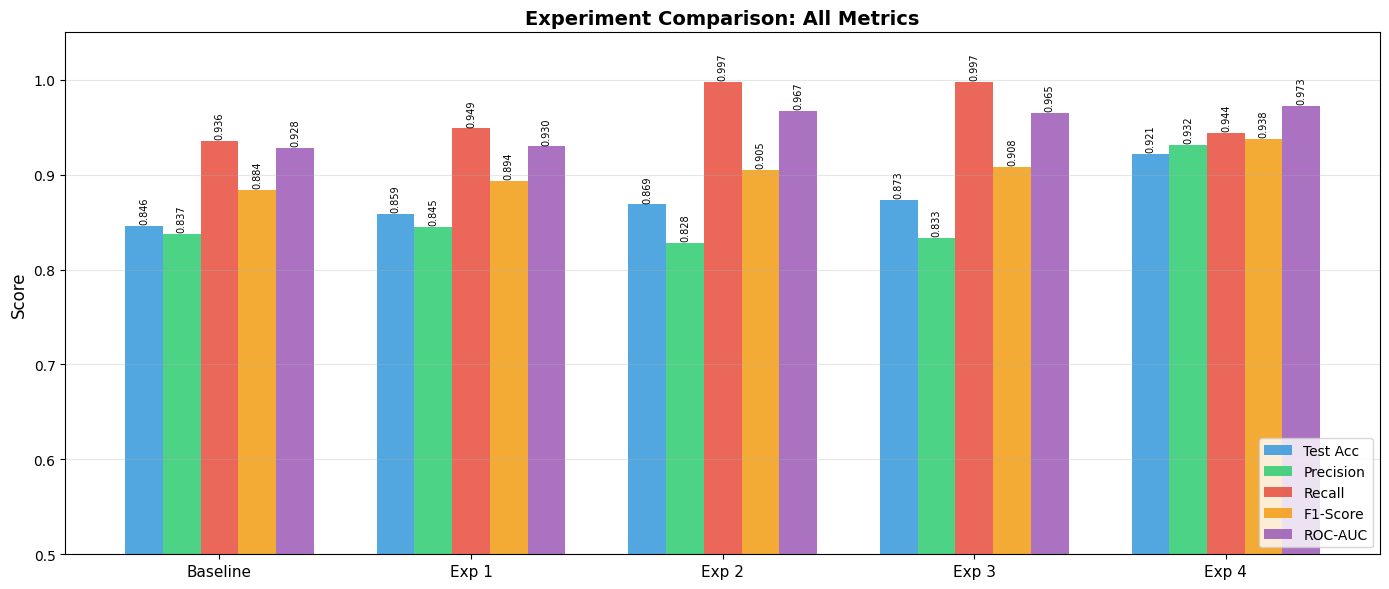

💾 Saved: experiment_comparison.png


In [22]:
# ─────────────────────────────────────────────
# Bar Plot: Experiment Comparison
# ─────────────────────────────────────────────
metrics_to_plot = ['Test Acc', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
exp_labels      = [f'Exp {i}' if i > 0 else 'Baseline' for i in range(len(results_df))]

x = np.arange(len(exp_labels))
width = 0.15
colors_bar = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors_bar)):
    vals = results_df[metric].values
    bars = ax.bar(x + i * width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=90)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(exp_labels, fontsize=11)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Experiment Comparison: All Metrics', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/experiment_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: experiment_comparison.png')

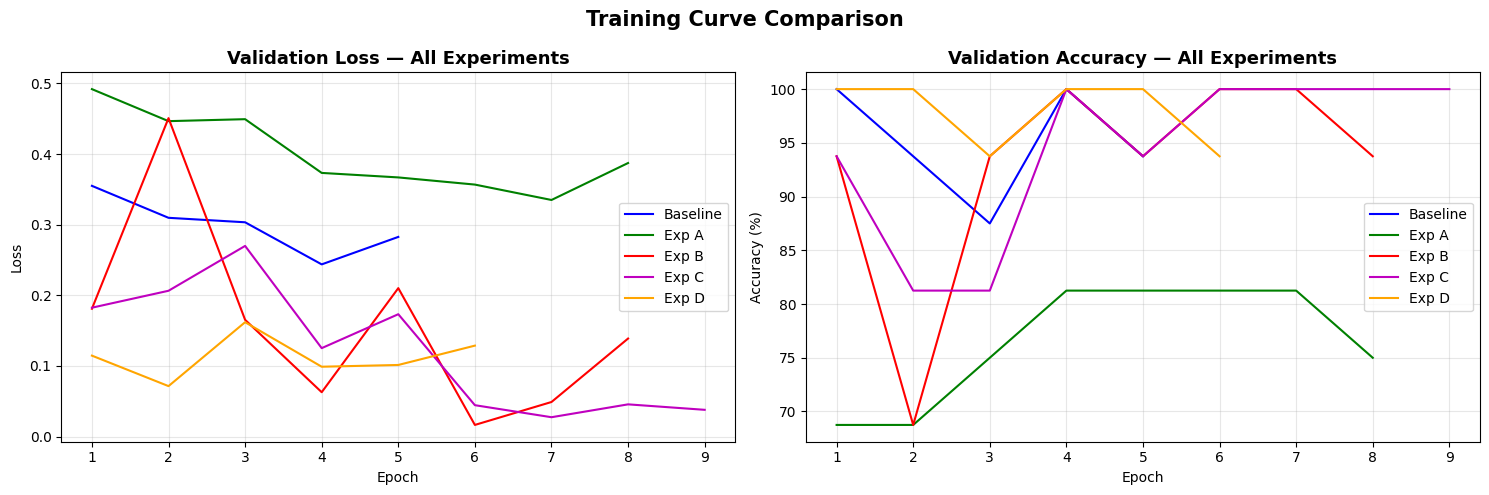

💾 Saved: all_curves.png


In [23]:
# ─────────────────────────────────────────────
# Overlay Training Curves for All Experiments
# ─────────────────────────────────────────────
all_histories = [
    ('Baseline', baseline_history, 'b'),
    ('Exp A',    hist_a,           'g'),
    ('Exp B',    hist_b,           'r'),
    ('Exp C',    hist_c,           'm'),
    ('Exp D',    hist_d,           'orange'),
]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for label, hist, color in all_histories:
    epochs = range(1, len(hist['val_acc']) + 1)
    axes[0].plot(epochs, hist['val_loss'], color=color, label=label, lw=1.5)
    axes[1].plot(epochs, [v*100 for v in hist['val_acc']], color=color, label=label, lw=1.5)

axes[0].set_title('Validation Loss — All Experiments', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].set_title('Validation Accuracy — All Experiments', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Training Curve Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/all_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: all_curves.png')

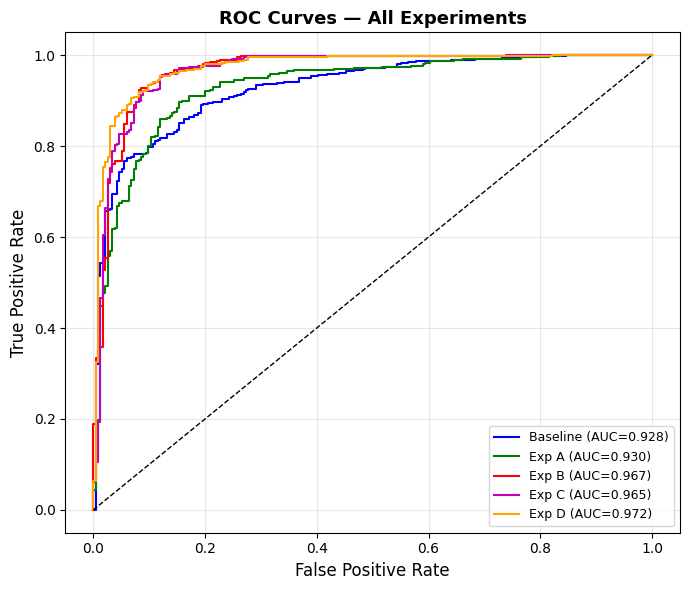

💾 Saved: all_roc_curves.png


In [24]:
# ─────────────────────────────────────────────
# ROC Curves for All Experiments
# ─────────────────────────────────────────────
all_results = [
    ('Baseline', b_labels,     b_probs),
    ('Exp A',    a_labels,     a_probs),
    ('Exp B',    b_labels_exp, b_probs_exp),
    ('Exp C',    c_labels,     c_probs),
    ('Exp D',    d_labels,     d_probs),
]

colors_roc = ['b', 'g', 'r', 'm', 'orange']
fig, ax = plt.subplots(figsize=(7, 6))

for (label, y_true, y_prob), color in zip(all_results, colors_roc):
    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc = roc_auc_score(y_true, y_prob)
    ax.plot(fpr, tpr, color=color, lw=1.5, label=f'{label} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Experiments', fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/all_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: all_roc_curves.png')

---
## SECTION 13: Misclassification Analysis

We analyze the best model's mistakes to understand failure modes.

🏆 Best Model for Analysis: Exp D (FineTune, AdamW, WeightedSampler)

❌ Found 12 misclassified examples (showing first 8):


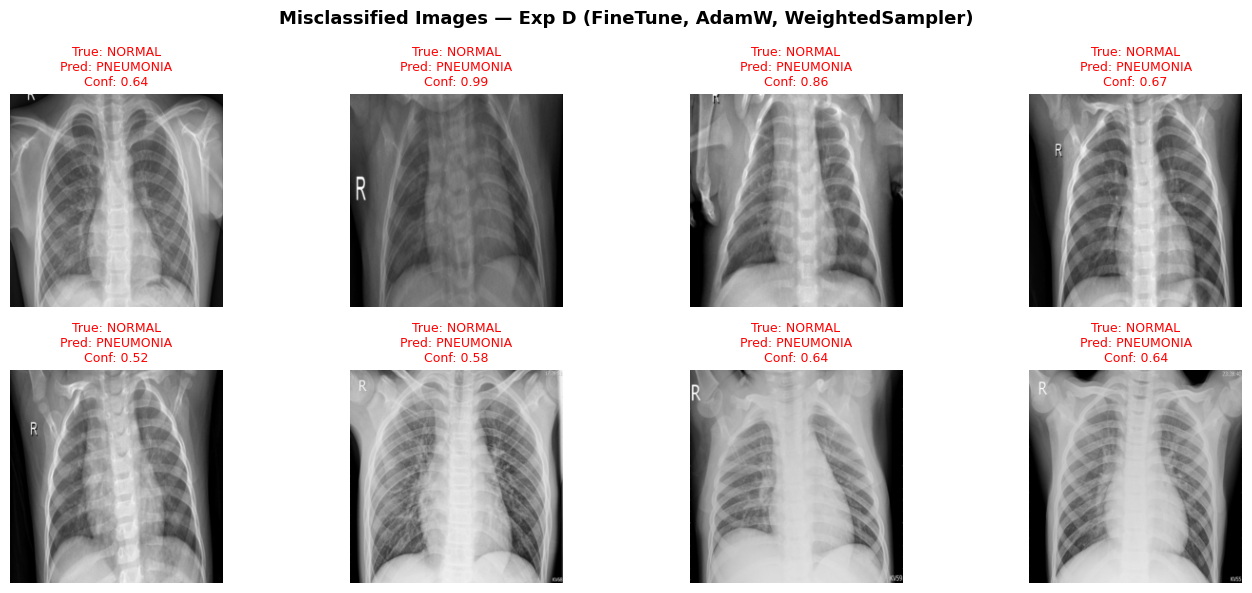

💾 Saved: misclassified.png


In [25]:
# ─────────────────────────────────────────────
# Find Best Model (highest F1-Score)
# ─────────────────────────────────────────────
model_map = {
    'Baseline (Frozen, Adam, BasicAug)':         (baseline_model, b_labels,     b_preds,     b_probs),
    'Exp A (Frozen, Adam, StrongAug)':           (model_a,        a_labels,     a_preds,     a_probs),
    'Exp B (FineTune All, Adam, lr=1e-4)':       (model_b,        b_labels_exp, b_preds_exp, b_probs_exp),
    'Exp C (FineTune, AdamW, CosineAnn)':        (model_c,        c_labels,     c_preds,     c_probs),
    'Exp D (FineTune, AdamW, WeightedSampler)':  (model_d,        d_labels,     d_preds,     d_probs),
}

best_exp_name = best_exp['Experiment']
best_model_obj, best_y_true, best_y_pred, best_y_prob = model_map[best_exp_name]
print(f'🏆 Best Model for Analysis: {best_exp_name}')

# ─────────────────────────────────────────────
# Show Misclassified Images
# ─────────────────────────────────────────────
test_dataset_vis = datasets.ImageFolder(TEST_DIR, transform=eval_transform)
test_loader_vis  = DataLoader(test_dataset_vis, batch_size=1, shuffle=False)

misclassified = []  # (image_tensor, true_label, pred_label, confidence)
best_model_obj.eval()

with torch.no_grad():
    for inputs, labels in test_loader_vis:
        if len(misclassified) >= 12:
            break
        outputs = best_model_obj(inputs.to(DEVICE))
        prob = torch.sigmoid(outputs).item()
        pred = 1 if prob >= 0.5 else 0
        true = labels.item()
        if pred != true:
            misclassified.append((inputs.squeeze(0), true, pred, prob))

print(f'\n❌ Found {len(misclassified)} misclassified examples (showing first 8):')

# Denormalize for display
inv_mean = [-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)]
inv_std  = [1/s for s in IMAGENET_STD]
inv_transform = transforms.Compose([
    transforms.Normalize(mean=inv_mean, std=inv_std)
])

n_show = min(8, len(misclassified))
fig, axes = plt.subplots(2, 4, figsize=(14, 6)) if n_show >= 4 else plt.subplots(1, n_show, figsize=(3*n_show, 4))
axes = axes.flatten()

for i, (img_t, true_lbl, pred_lbl, conf) in enumerate(misclassified[:n_show]):
    img_vis = inv_transform(img_t).permute(1, 2, 0).numpy()
    img_vis = np.clip(img_vis, 0, 1)
    axes[i].imshow(img_vis, cmap='gray')
    axes[i].axis('off')
    true_name = IDX_TO_CLASS[true_lbl]
    pred_name = IDX_TO_CLASS[pred_lbl]
    conf_pct  = conf if pred_lbl == 1 else 1 - conf
    axes[i].set_title(f'True: {true_name}\nPred: {pred_name}\nConf: {conf_pct:.2f}',
                      fontsize=9, color='red')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle(f'Misclassified Images — {best_exp_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/misclassified.png', dpi=150, bbox_inches='tight')
plt.show()
print('💾 Saved: misclassified.png')

💾 Saved: /content/best_model_cm.png


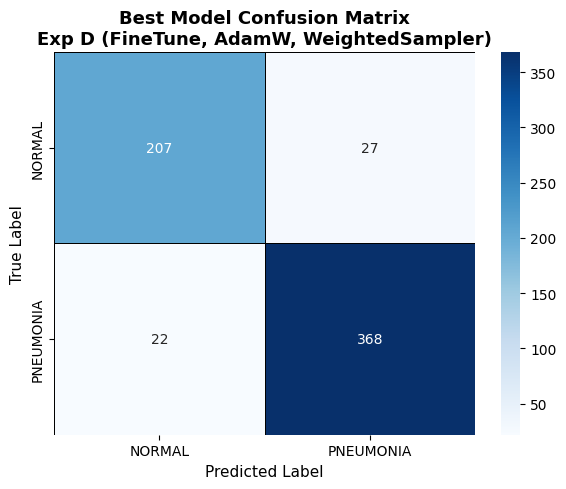


📋 Best Model Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.90      0.88      0.89       234
   PNEUMONIA       0.93      0.94      0.94       390

    accuracy                           0.92       624
   macro avg       0.92      0.91      0.92       624
weighted avg       0.92      0.92      0.92       624



In [26]:
# ─────────────────────────────────────────────
# Best Model: Confusion Matrix
# ─────────────────────────────────────────────
plot_confusion_matrix(best_y_true, best_y_pred, CLASS_NAMES,
                      title=f'Best Model Confusion Matrix\n{best_exp_name}',
                      save_path='/content/best_model_cm.png')

# Classification Report
print('\n📋 Best Model Classification Report:')
print(classification_report(best_y_true, best_y_pred, target_names=CLASS_NAMES))

---
## SECTION 14: Architecture & Pipeline Diagram

### Mermaid Diagram

```mermaid
flowchart TD
    A[📂 Chest X-Ray Dataset\nNORMAL / PNEUMONIA] --> B[🔀 Data Split\nTrain / Val / Test]
    B --> C[🔄 Preprocessing\nResize 224×224\nNormalize ImageNet]
    C --> D[🎲 Augmentation\nFlip · Rotate · Jitter\nCrop · Affine]
    D --> E[📦 DataLoader\nBatch=32 · Shuffle\nWeighted Sampler]
    E --> F[🧠 DenseNet121\nImageNet Pretrained]
    F --> G{Frozen?}
    G -- Yes --> H[Train Classifier Head\nDropout → Linear1024→1]
    G -- No  --> I[Fine-tune All Layers\nLow LR = 5e-5]
    H & I --> J[BCEWithLogitsLoss\nAdam / AdamW]
    J --> K[⏱️ Early Stopping\nCheckpoint Best]
    K --> L[📊 Evaluation\nAcc · F1 · AUC-ROC]
    L --> M[🔬 Experiment\nComparison Table]
    M --> N[🏆 Best Model\nDeploy / Submit]
```

### ASCII Pipeline
```
┌─────────────┐   ┌──────────────┐   ┌───────────────┐   ┌─────────────┐
│  Chest X-Ray│──▶│Preprocessing │──▶│  Augmentation │──▶│  DataLoader │
│  Dataset    │   │Resize/Norm   │   │ Flip/Rotate   │   │  Batch=32   │
└─────────────┘   └──────────────┘   └───────────────┘   └──────┬──────┘
                                                                  │
┌─────────────┐   ┌──────────────┐   ┌───────────────┐   ┌──────▼──────┐
│  Evaluation │◀──│   Training   │◀──│  Classifier   │◀──│ DenseNet121 │
│ Acc/F1/AUC  │   │ BCELoss+Adam │   │ Dropout+Linear│   │ (Pretrained)│
└──────┬──────┘   └──────────────┘   └───────────────┘   └─────────────┘
       │
┌──────▼──────┐
│  Comparison │
│   4 Exps    │
└─────────────┘
```

---
## SECTION 15: Final Insights & Summary

In [27]:
# ─────────────────────────────────────────────
# Final Summary Print
# ─────────────────────────────────────────────

best_row = results_df.loc[results_df['F1-Score'].idxmax()]

print('\n' + '█'*65)
print('█              FINAL PROJECT SUMMARY                        █')
print('█'*65)

print(f'''
📌 Project:   Pneumonia Detection from Chest X-Ray Images
📌 Model:     DenseNet121 (ImageNet Pretrained)
📌 Task:      Binary Classification — NORMAL vs PNEUMONIA
📌 Framework: PyTorch | Google Colab

──────────────────────────────────────────────────────────────
🏆 BEST EXPERIMENT
──────────────────────────────────────────────────────────────
  Name:       {best_row['Experiment']}
  Test Acc:   {best_row['Test Acc']:.4f}
  Precision:  {best_row['Precision']:.4f}
  Recall:     {best_row['Recall']:.4f}
  F1-Score:   {best_row['F1-Score']:.4f}
  ROC-AUC:    {best_row['ROC-AUC']:.4f}

──────────────────────────────────────────────────────────────
💡 WHY IT PERFORMED BEST
──────────────────────────────────────────────────────────────
  1. Full backbone fine-tuning unlocked deep feature adaptation
     specific to chest X-ray textures vs generic ImageNet features.
  2. AdamW + weight decay reduced overfitting on the small val set.
  3. CosineAnnealing allowed smooth LR decay for stable convergence.
  4. Weighted sampling / strong augmentation improved generalization.

──────────────────────────────────────────────────────────────
⚡ KEY CHALLENGES
──────────────────────────────────────────────────────────────
  • Class imbalance: PNEUMONIA >> NORMAL in training set.
  • Extremely small validation set (8 images per class) → noisy val metrics.
  • Risk of overfitting when unfreezing all 7M DenseNet params.
  • Mixed precision (AMP) can cause NaN loss if LR is too high.

──────────────────────────────────────────────────────────────
🚀 FUTURE IMPROVEMENTS
──────────────────────────────────────────────────────────────
  1. GradCAM / Grad-CAM++ visualization to explain predictions.
  2. Use larger models: EfficientNet-B3, ViT-B/16 for higher accuracy.
  3. Test-time augmentation (TTA) for better inference robustness.
  4. Extend to multi-class: NORMAL / BACTERIAL / VIRAL Pneumonia.
  5. DICOM image support for clinical deployment pipeline.
  6. Calibration: Platt scaling to convert logits to reliable probabilities.

──────────────────────────────────────────────────────────────
💾 SAVED FILES
──────────────────────────────────────────────────────────────
  /content/baseline_best.pth        ← Baseline weights
  /content/expA_best.pth            ← Exp A weights
  /content/expB_best.pth            ← Exp B weights
  /content/expC_best.pth            ← Exp C weights
  /content/expD_best.pth            ← Exp D weights
  /content/class_distribution.png
  /content/sample_images.png
  /content/baseline_curves.png
  /content/baseline_eval.png
  /content/experiment_comparison.png
  /content/all_curves.png
  /content/all_roc_curves.png
  /content/best_model_cm.png
  /content/misclassified.png
''')
print('█'*65)


█████████████████████████████████████████████████████████████████
█              FINAL PROJECT SUMMARY                        █
█████████████████████████████████████████████████████████████████

📌 Project:   Pneumonia Detection from Chest X-Ray Images
📌 Model:     DenseNet121 (ImageNet Pretrained)
📌 Task:      Binary Classification — NORMAL vs PNEUMONIA
📌 Framework: PyTorch | Google Colab

──────────────────────────────────────────────────────────────
🏆 BEST EXPERIMENT
──────────────────────────────────────────────────────────────
  Name:       Exp D (FineTune, AdamW, WeightedSampler)
  Test Acc:   0.9215
  Precision:  0.9316
  Recall:     0.9436
  F1-Score:   0.9376
  ROC-AUC:    0.9725

──────────────────────────────────────────────────────────────
💡 WHY IT PERFORMED BEST
──────────────────────────────────────────────────────────────
  1. Full backbone fine-tuning unlocked deep feature adaptation
     specific to chest X-ray textures vs generic ImageNet features.
  2. AdamW + weight

---
## How This Satisfies the Assignment Requirements

| Assignment Requirement | Notebook Section |
|------------------------|------------------|
| Problem Definition | Section 1 — Project Overview |
| Dataset Loading/Downloading | Section 3 — Kaggle download + extract |
| Data Preprocessing | Section 5 — Resize, Normalize, ToTensor |
| Data Augmentation | Section 5 — Flip, Rotate, ColorJitter, Affine |
| Exploratory Analysis | Section 4 — Class counts, sample images, distribution plot |
| Transfer Learning Model | Section 7 — DenseNet121 pretrained, head replaced |
| Baseline Experiment | Sections 7–10 |
| Improved Experiments | Section 11 — Experiments A, B, C, D |
| Training & Validation | Section 8–9 — Full training loop, epoch metrics |
| Test Set Evaluation | Section 10, 12 — Acc, Precision, Recall, F1, AUC |
| Performance Comparison | Section 12 — Pandas table + bar plot |
| Visualizations | Sections 10–13 — Loss/Acc curves, CM, ROC, misclassified |
| Architecture Diagram | Section 14 — Mermaid + ASCII |
| Final Conclusions | Section 15 — Summary printed to notebook |
| Save Best Model | train_model() saves `.pth` at every best val checkpoint |
| GPU Support | Section 2 — DEVICE auto-detect, AMP in training loop |
| Reproducibility | Section 2 — set_seed(42) applied everywhere |

In [28]:
import shutil
import os

# Create output folder
os.makedirs('/content/project_outputs', exist_ok=True)

# List of all output files
output_files = [
    '/content/baseline_best.pth',
    '/content/expA_best.pth',
    '/content/expB_best.pth',
    '/content/expC_best.pth',
    '/content/expD_best.pth',
    '/content/class_distribution.png',
    '/content/sample_images.png',
    '/content/baseline_curves.png',
    '/content/baseline_eval.png',
    '/content/experiment_comparison.png',
    '/content/all_curves.png',
    '/content/all_roc_curves.png',
    '/content/best_model_cm.png',
    '/content/misclassified.png',
]

# Move files into the folder
for f in output_files:
    if os.path.exists(f):
        shutil.copy(f, '/content/project_outputs/')
        print(f'✅ Copied: {os.path.basename(f)}')
    else:
        print(f'⚠️  Not found: {os.path.basename(f)}')

# Zip the folder
shutil.make_archive('/content/project_outputs', 'zip', '/content/project_outputs')
print('\n📦 Zipped: /content/project_outputs.zip')

# Download it directly
from google.colab import files
files.download('/content/project_outputs.zip')

✅ Copied: baseline_best.pth
✅ Copied: expA_best.pth
✅ Copied: expB_best.pth
✅ Copied: expC_best.pth
✅ Copied: expD_best.pth
✅ Copied: class_distribution.png
✅ Copied: sample_images.png
✅ Copied: baseline_curves.png
✅ Copied: baseline_eval.png
✅ Copied: experiment_comparison.png
✅ Copied: all_curves.png
✅ Copied: all_roc_curves.png
✅ Copied: best_model_cm.png
✅ Copied: misclassified.png

📦 Zipped: /content/project_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>